In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

from blackhole.constants import M_sun
from blackhole.disk_physics import R_func, X_func, kinematic_viscosity
from blackhole.luminosity import L_rad, L_rad_array, T_eff

# ---------------------------------------------------------------------------
# White Dwarf parameters (must match wd_timedep_simulation.ipynb)
# ---------------------------------------------------------------------------
M_wd = M_sun

R_1 = 5e8
R_K = 2.1e10
R_N = 8e10

X_1 = X_func(R_1)
X_N = X_func(R_N)
N = 100
N_n = 3

X = np.linspace(X_1, X_N, N)
dX = float(np.diff(X)[0])
X = np.linspace(X_1, X_N + N_n * dX, N + N_n)
r = R_func(X)
dr = np.diff(r)
dr = np.insert(dr, 0, 0)
dX = float(np.diff(X)[0])
X_N = X_N + N_n * dX
N = N + N_n

In [2]:
# ---------------------------------------------------------------------------
# Load simulation data
# ---------------------------------------------------------------------------
DATA_PREFIX = "../data/"
DATA_SUFFIX = "_history_bath_array_wd.csv"

Sigma_history = np.array(
    pd.read_csv(DATA_PREFIX + "Sigma" + DATA_SUFFIX, header=None).to_numpy()
)
Temp_history = np.array(
    pd.read_csv(DATA_PREFIX + "Temp" + DATA_SUFFIX, header=None).to_numpy()
)
H_history = np.array(
    pd.read_csv(DATA_PREFIX + "H" + DATA_SUFFIX, header=None).to_numpy()
)
alpha_history = np.array(
    pd.read_csv(DATA_PREFIX + "alpha" + DATA_SUFFIX, header=None).to_numpy()
)
t_history = np.array(
    pd.read_csv(DATA_PREFIX + "t" + DATA_SUFFIX, header=None).to_numpy().flatten()
)
Sigma_transfer_history = np.array(
    pd.read_csv(DATA_PREFIX + "Sigma_transfer" + DATA_SUFFIX, header=None).to_numpy().flatten()
)

print(f"Loaded {len(t_history)} snapshots, t = [{t_history[0]:.2e}, {t_history[-1]:.2e}] s")
print(f"Sigma shape: {Sigma_history.shape}")

Loaded 200001 snapshots, t = [0.00e+00, 2.43e+08] s
Sigma shape: (200001, 103)


In [3]:
# ---------------------------------------------------------------------------
# Compute luminosity arrays
# ---------------------------------------------------------------------------
L_array = np.array([
    L_rad(Sigma_history[i], H_history[i], alpha_history[i], r, dr, M_wd)
    for i in range(len(t_history))
])

L_rad_arr = np.vstack([
    L_rad_array(Sigma_history[i], H_history[i], alpha_history[i], r, dr, M_wd)
    for i in range(len(t_history))
])

T_eff_arr = np.vstack([
    T_eff(Sigma_history[i], H_history[i], alpha_history[i], r, M_wd)
    for i in range(len(t_history))
])

print(f"L range: [{L_array.min():.2e}, {L_array.max():.2e}] erg/s")

L range: [5.83e+25, 1.04e+35] erg/s


In [4]:
# ---------------------------------------------------------------------------
# Plotting helpers
# ---------------------------------------------------------------------------
SECONDS_PER_YEAR = 31536000


def setup_ticks(ax):
    ax.tick_params(axis='both', which='major', direction='in',
                   length=16, width=2)
    ax.tick_params(axis='both', which='minor', direction='in',
                   length=8, width=2)
    ax.tick_params(axis='both', which='both',
                   top=True, right=True, direction='in')
    ax.tick_params(labeltop=False, labelright=False)

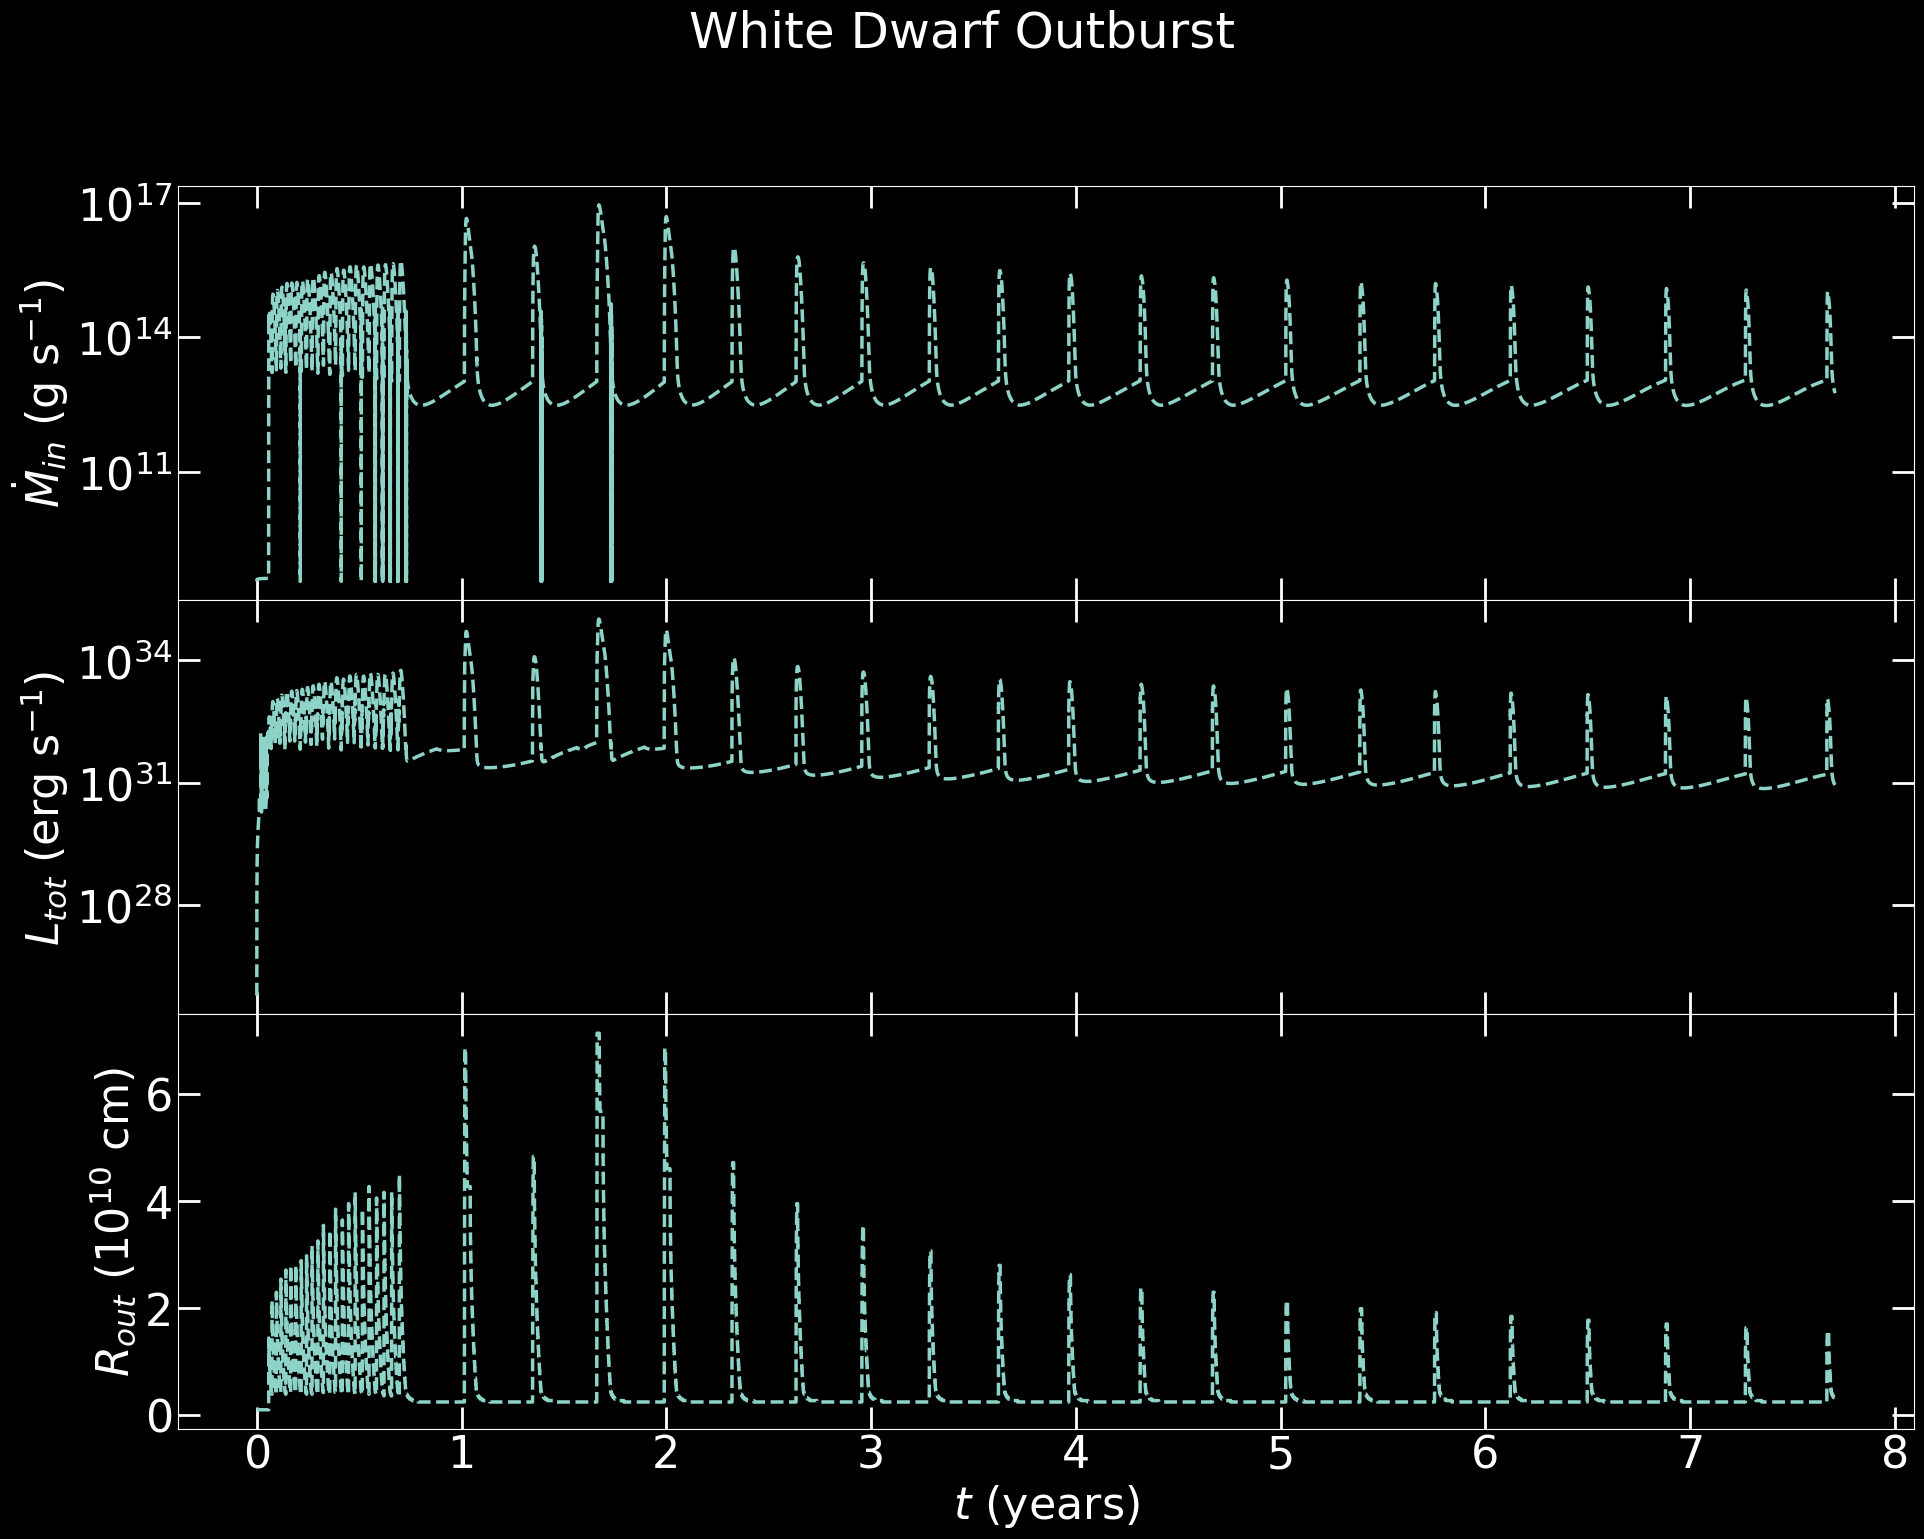

In [5]:
# ---------------------------------------------------------------------------
# Plot: Mass transfer rate, Luminosity, Outer radius vs time
# ---------------------------------------------------------------------------
plt.rcParams.update({'font.size': 32})

# Inner-edge mass accretion rate: M_dot_in = 2*pi*r * Sigma * 3*nu / r
index = 1  # radial index to sample inner accretion rate
M_dot_in = np.array([
    2 * np.pi * r[index] * Sigma_history[i, index] * 3
    * kinematic_viscosity(H_history[i, index], r[index],
                          alpha_history[i, index], M_wd)
    / r[index]
    for i in range(len(t_history))
])

# Outer radius: first index (from inner edge outward) where T < 5000 K
first_indices = np.full(Temp_history.shape[0], 1)
for ts in range(Temp_history.shape[0]):
    cold = np.where(Temp_history[ts, 3:] < 5000)[0]
    if cold.size > 0:
        first_indices[ts] = cold[0] + 3
R_out = r[first_indices] / 1e10  # in units of 10^10 cm

t_years = t_history / SECONDS_PER_YEAR

fig, axs = plt.subplots(3, 1, figsize=(20, 16), gridspec_kw={'hspace': 0})
ax1, ax2, ax3 = axs

# Plain number formatting on all x-axes (must set before hiding labels)
fmt = plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
for ax in axs:
    ax.xaxis.set_major_formatter(fmt)

# --- Mass transfer rate ---
ax1.plot(t_years, M_dot_in, linewidth=2.5, linestyle='dashed')
ax1.set_ylabel(r'$\dot{M}_{in}$ (g s$^{-1}$)')
ax1.set_yscale('log')
ax1.tick_params(labelbottom=False)
setup_ticks(ax1)

# --- Luminosity ---
ax2.plot(t_years, L_array, linewidth=2.5, linestyle='dashed')
ax2.set_ylabel(r'$L_{tot}$ (erg s$^{-1}$)')
ax2.set_yscale('log')
ax2.tick_params(labelbottom=False)
setup_ticks(ax2)

# --- Outer radius ---
ax3.plot(t_years, R_out, linewidth=2.5, linestyle='dashed')
ax3.set_xlabel(r'$t$ (years)')
ax3.set_ylabel(r'$R_{out}$ ($10^{10}$ cm)')
setup_ticks(ax3)

fig.suptitle('White Dwarf Outburst', fontsize=36, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('../graphs/wd_outburst.png', dpi=150, bbox_inches='tight')
plt.show()